In [1]:
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm


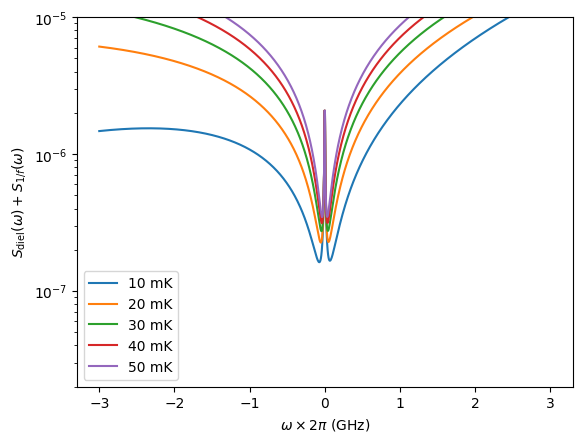

In [49]:
hbar = 1/(2*np.pi)
kB = 8.617333262e-5  # eV K−1
hbar_in_eVs = 6.5821e-16  # eV s

def diel_spectral_density(omega, EC,temp_in_mK = 42 ):

    beta = 1 / (kB * temp_in_mK * 1e-3)  # 1/eV

    coth_arg = beta * hbar_in_eVs * np.abs(omega) / 2  # s GHZ
    coth_arg *= 1e9  # dimensionless
    return_val = np.where(omega < 0, 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) - 1) , 
                          1/2 * np.abs( 1 / np.tanh(coth_arg) + 1) )

    omega_ref = 2*np.pi *6 # GHz
    epsilon = 0.15
    Q_cap = 1/(  2* 1e-5 * np.abs(omega/omega_ref)**epsilon ) 

    return_val *= hbar * np.abs(omega)**2   / (4 * EC * Q_cap)  # GHZ^2/GHZ = GHZ


    return return_val

def one_over_f_spectral_density(omega, EL,one_over_f_flux_noise_amplitude ):
    return_val = 2 * np.pi # dimensionless
    return_val *= (EL / hbar)**2  # GHz^2
    return_val *= one_over_f_flux_noise_amplitude**2  # GHz^2
    return_val /= omega  # GHz
    return np.abs(return_val)



temp_list = [10,20,30,40,50]
omega_array = np.linspace(-3,3,1000)

eta = 5e-5
EC = 3/8
EL = 3/30
for temp in temp_list:
    gamma_diel = diel_spectral_density(omega_array, EC,temp )
    gamma_one_over_f = one_over_f_spectral_density(omega_array, EL,eta)
    plt.plot(omega_array, gamma_diel+gamma_one_over_f,label = f"{temp} mK")

plt.ylim(2e-8,1e-5)
plt.yscale('log')
plt.xlabel(rf"$\omega \times 2\pi$ (GHz)")
plt.ylabel(rf"$S_\text{{diel}}(\omega)+S_{{1/f}}(\omega)$")
plt.legend()

In [42]:
EJ = 3
EJ_over_EL_list = np.linspace(20,45,51)
EJ_over_EC_list = np.linspace(2,12,101)
X, Y = np.meshgrid(EJ_over_EC_list,EJ_over_EL_list)

import pickle
with open('data_v4_large_inductance.data', 'rb') as f:
    (EJ_over_EL_list, EJ_over_EC_list, EJ_over_EC_array, EJ_over_EL_array,
                 upside_down_phi_element01_array , upside_down_phi_element12_array ,
                   upside_down_freq01_array , upside_down_freq12_array ,
                     conventional_phi_element_array ,conventional_freq_array ,
                    upside_down_2nd_order_01_array ,upside_down_2nd_order_12_array ,conventional_2nd_order_array   ) = pickle.load(f)


In [43]:
def T_phi(second_order_derivative, one_over_f_flux_noise_amplitude):  # eqn (13) of Peter Groszkowski et al 2018 New J. Phys. 20 043053
    omega_uv = 3 * 2 * np.pi  # GHz
    omega_ir = 1e-9 * 2 * np.pi  # GHz
    t = 10e3  # ns
    A = one_over_f_flux_noise_amplitude  # in unit of Phi0
    return_val = 2 * A**4 * second_order_derivative**2  # Phi0^4 GHZ^2 / Phi0^4
    return_val *= (np.log(omega_uv / omega_ir)**2 + 2 * np.log(omega_ir * t)**2)  # GHZ^2
    return_val = return_val**(-1/2)  # ns
    return return_val  # Seems the unit here should be millisecond? Where did miss a 1e3?


In [44]:
hbar = 1/(2*np.pi)

def compute_lifetimes(one_over_f_flux_noise_amplitude,temp_in_mK):
    conventional_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    conventional_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down01_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down01_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    upside_down12_dielectric_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_one_over_f_loss_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))
    upside_down12_dephasing_lifetime = np.zeros((len(EJ_over_EL_list), len(EJ_over_EC_list)))

    for i in range(len(EJ_over_EL_list)):
        for j in range(len(EJ_over_EC_list)):
            EC = EJ / EJ_over_EC_list[j]
            EL = EJ / EJ_over_EL_list[i]

            # Conventional lifetimes
            omega_conventional = conventional_freq_array[i, j] * 2 * np.pi
            phi_conventional = conventional_phi_element_array[i, j]
            second_order_conventional = conventional_2nd_order_array[i, j]

            conventional_dielectric_lifetime[i, j] = 1 / (np.abs(phi_conventional)**2 * diel_spectral_density(omega_conventional, EC,temp_in_mK ))
            conventional_one_over_f_loss_lifetime[i, j] = 1 / (np.abs(phi_conventional)**2 * one_over_f_spectral_density(omega_conventional, EL,one_over_f_flux_noise_amplitude )) 
            conventional_dephasing_lifetime[i, j] = T_phi(second_order_conventional, one_over_f_flux_noise_amplitude)

            # Upside down 12 lifetimes
            omega_upside_down12 = upside_down_freq12_array[i, j] * 2 * np.pi
            phi_upside_down12 = upside_down_phi_element12_array[i, j]
            second_order_upside_down12 = upside_down_2nd_order_12_array[i, j]

            upside_down12_dielectric_lifetime[i, j] = 1 / (np.abs(phi_upside_down12)**2 * diel_spectral_density(omega_upside_down12, EC,temp_in_mK ))
            upside_down12_one_over_f_loss_lifetime[i, j] = 1 / (np.abs(phi_upside_down12)**2 * one_over_f_spectral_density(omega_upside_down12, EL,one_over_f_flux_noise_amplitude )) 
            upside_down12_dephasing_lifetime[i, j] = T_phi(second_order_upside_down12, one_over_f_flux_noise_amplitude)

    return {
        "conventional_dielectric_lifetime": conventional_dielectric_lifetime,
        "conventional_one_over_f_loss_lifetime": conventional_one_over_f_loss_lifetime,
        "conventional_dephasing_lifetime": conventional_dephasing_lifetime,
        "upside_down01_dielectric_lifetime": upside_down01_dielectric_lifetime,
        "upside_down01_one_over_f_loss_lifetime": upside_down01_one_over_f_loss_lifetime,
        "upside_down01_dephasing_lifetime": upside_down01_dephasing_lifetime,
        "upside_down12_dielectric_lifetime": upside_down12_dielectric_lifetime,
        "upside_down12_one_over_f_loss_lifetime": upside_down12_one_over_f_loss_lifetime,
        "upside_down12_dephasing_lifetime": upside_down12_dephasing_lifetime
    }

In [45]:
combinations = [[4e-6, 20], 
                [2e-6, 20], 
                [1.4e-6, 20],
                [5e-7, 20]]

tot_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_dielectric_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
T1_1overf_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}
Tphi_results = { 
    "conventional": [],
    "upside_down01": [],
    "upside_down12": []
}

for amplitude, temp in combinations:
    lifetimes = compute_lifetimes(amplitude, temp)
    for catagory in ["conventional", "upside_down01", "upside_down12"]:
        dephasing_T = lifetimes[catagory+"_dephasing_lifetime"] / 1e6
        T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
        tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))
        Tphi_results[catagory].append(dephasing_T)
        T1_results[catagory].append(T1_tot)
        T1_dielectric_results[catagory].append(lifetimes[catagory+"_dielectric_lifetime"]/1e6)
        T1_1overf_results[catagory].append(lifetimes[catagory+"_one_over_f_loss_lifetime"]/1e6)

/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_39442/3607120959.py:36: RuntimeWarning: divide by zero encountered in divide
  T1_tot = 2/(1/lifetimes[catagory+"_one_over_f_loss_lifetime"] + 1/lifetimes[catagory+"_dielectric_lifetime"])/1e6
/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_39442/3607120959.py:37: RuntimeWarning: divide by zero encountered in divide
  tot_results[catagory].append(1/(2/T1_tot + 1/dephasing_T))


/var/folders/9k/z8bpg3hj3d9841ggs75xmwxw0000gn/T/ipykernel_39442/2683273093.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()  # Adjust layout to minimize extra white space


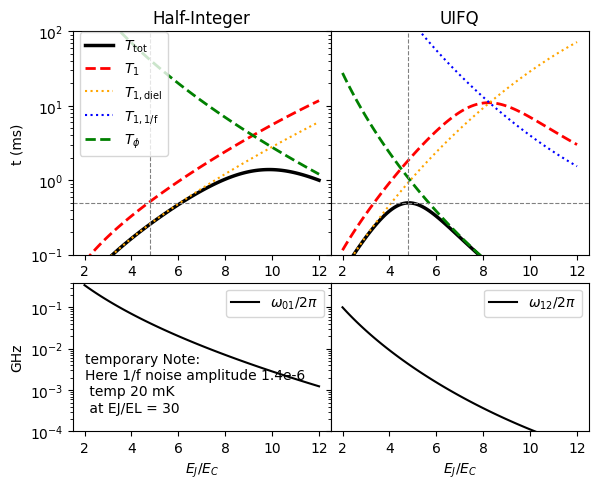

In [46]:
import matplotlib.pyplot as plt

# Assuming you have defined your data and variables before this snippet

fig = plt.figure(figsize=(6, 5))  # Adjusted total figure height

# Define gridspec with custom spacing and height ratios
gs = fig.add_gridspec(nrows=2, ncols=2, height_ratios=[3, 2], hspace=0.15, wspace=0.0, left=0.12, right=0.98, top=0.92, bottom=0.12)

# Axes for the first row
axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1])]  # sharey ensures the same y-axis scale

# Axes for the second row
axes_row2 = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])]

EL_idx = 20
noise_profile_idx = -2

frequencys = {
    "conventional":conventional_freq_array,
    "upside_down12":upside_down_freq12_array
}
phi_ele = {
    "conventional":conventional_phi_element_array,
    "upside_down12":upside_down_phi_element12_array
}
for i, (category, title) in enumerate(zip(["conventional", "upside_down12"],
                                          ['Half-Integer', 'UIFQ'])):
    for j, (results, name, color, line, width) in enumerate(zip([tot_results, T1_results, T1_dielectric_results, T1_1overf_results, Tphi_results],
                                                               [rf'$T_\text{{tot}}$', rf'$T_1$', rf'$T_{{1,\text{{diel}}}}$', rf'$T_{{1,\text{{1/f}}}}$', rf'$T_\phi$'],
                                                               ['black', 'red', 'orange', 'blue', 'green'],
                                                               ['solid', 'dashed', 'dotted', 'dotted', 'dashed'],
                                                               [2.5, 2, 1.5, 1.5, 2])):
        axes[i].plot(EJ_over_EC_list, results[category][noise_profile_idx][EL_idx, :], label=name, color=color, linestyle=line, linewidth=width)

    axes[i].set_yscale('log')
    axes[i].set_ylim(1e-1, 1e2)
    axes[i].set_title(title)
    # axes[i].set_xlabel(rf'$E_J/E_C$')
    if i == 0:
        axes[i].set_ylabel("t (ms)")

    line_y = max(tot_results['upside_down12'][noise_profile_idx][EL_idx, :])
    line_x = np.argmax(tot_results['upside_down12'][noise_profile_idx][EL_idx, :])
    axes[i].axhline(y=line_y, color='grey', linestyle='--',linewidth=0.8)
    axes[i].axvline(x=EJ_over_EC_list[line_x], color='grey', linestyle='--',linewidth=0.8)

for i, (category, name) in enumerate(zip(["conventional", "upside_down12"],
                                         [rf'$\omega_\text{{01}}/2\pi$',rf'$\omega_\text{{12}}/2\pi$'])):
    axes_row2[i].plot(EJ_over_EC_list, frequencys[category][EL_idx, :],label=name,color='black')
    axes_row2[i].set_ylim(1e-4, 4e-1)
    axes_row2[i].set_yscale('log')
    axes_row2[i].legend()
    axes_row2[i].set_xlabel(rf'$E_J/E_C$')
    if i == 0:
        axes_row2[i].set_ylabel("GHz")

# Remove yticks from the second subplot of the first row
plt.setp(axes[1].get_yticklabels(), visible=False)
plt.setp(axes_row2[1].get_yticklabels(), visible=False)

# Add legend to the first subplot with adjusted position
axes[0].legend(loc='center left', bbox_to_anchor=(0.0, 0.72))
axes_row2[0].text(2,3e-4,"temporary Note: \nHere 1/f noise amplitude 1.4e-6\n temp 20 mK\n at EJ/EL = 30")
# Now you can use axes_row2 for the second row plots later
plt.tight_layout()  # Adjust layout to minimize extra white space
plt.savefig('fig02_2d.pdf')
plt.show()


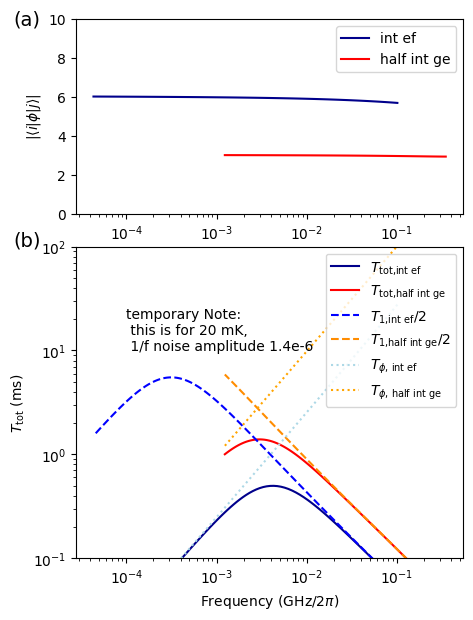

In [72]:
fig, axes = plt.subplots(2,1,figsize = (5,7),height_ratios=[1,1.6])
plt.subplots_adjust(hspace=0.13)
EL_idx = 20
noise_profile_idx = -2
axes[0].plot()
axes[0].plot(frequencys["upside_down12"][EL_idx, :],phi_ele["upside_down12"][EL_idx, :], label = rf'int ef',color = 'darkblue')
axes[0].plot(frequencys["conventional"][EL_idx, :],phi_ele["conventional"][EL_idx, :], label = rf'half int ge',color = 'red')
axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_ylim(0,10)
# axes[0].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[0].set_ylabel(r'$| \langle i | \phi | j \rangle|$')


axes[1].plot(frequencys["upside_down12"][EL_idx, :],tot_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_\text{{tot,int ef}}$',color = 'darkblue')
axes[1].plot(frequencys["conventional"][EL_idx, :],tot_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_\text{{tot,half int ge}}$',color = 'red')

axes[1].plot(frequencys["upside_down12"][EL_idx, :],T1_results["upside_down12"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_\text{{1,int ef}}$/2',color = 'blue', linestyle='dashed')
axes[1].plot(frequencys["conventional"][EL_idx, :],T1_results["conventional"][noise_profile_idx][EL_idx, :]/2, label = rf'$T_\text{{1,half int ge}}/2$',color = 'darkorange', linestyle='dashed')

axes[1].plot(frequencys["upside_down12"][EL_idx, :],Tphi_results["upside_down12"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, int ef}}}}$',color = 'lightblue', linestyle='dotted')
axes[1].plot(frequencys["conventional"][EL_idx, :],Tphi_results["conventional"][noise_profile_idx][EL_idx, :], label = rf'$T_{{\phi \text{{, half int ge}}}}$',color = 'orange', linestyle='dotted')


axes[1].text(1e-4,1e1,"temporary Note: \n this is for 20 mK,  \n 1/f noise amplitude 1.4e-6")

axes[1].legend(loc='upper right')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-1,1e2)
axes[1].set_xlabel(r'Frequency (GHz/$2\pi$)')
axes[1].set_ylabel(rf'$T_\text{{tot}}$ (ms)')

axes[0].text(-0.16, 1.05, '(a)', transform=axes[0].transAxes, fontsize=14, verticalalignment='top')
axes[1].text(-0.16, 1.05, '(b)', transform=axes[1].transAxes, fontsize=14, verticalalignment='top')

plt.savefig('phi_element vs freq.pdf')
